In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
/home/nmldata2/ccaw/Python
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 40)
Valid windows: (101861, 40)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


In [2]:
session_day_df

,animal,date,phase,session_duration_s,n_events_total,n_events_valid,short_recording,enough_valid_events,good_session_basic,nwin_LED_off_post,...,nwin_tone_off_post,nwin_tone_off_pre,nwin_tone_on_post,nwin_tone_on_pre,n_valid_windows_total,date_dt,phase_day_number_good,n_good_sessions_in_phase,normalized_phase_day_good,phase_day_bin
0,NML_04,2025_12_27,habituation,1310.8,42,42,False,True,True,42,...,0,0,0,0,503,2025-12-27,1.0,16.0,0.000000,early
1,NML_04,2025_12_28,habituation,1473.4,43,43,False,True,True,43,...,0,0,0,0,516,2025-12-28,2.0,16.0,0.066667,early
2,NML_04,2025_12_29,habituation,1254.5,41,41,False,True,True,41,...,0,0,0,0,492,2025-12-29,3.0,16.0,0.133333,early
3,NML_04,2025_12_30,habituation,1624.2,53,53,False,True,True,53,...,0,0,0,0,636,2025-12-30,4.0,16.0,0.200000,early
4,NML_04,2025_12_31,habituation,1326.6,41,41,False,True,True,41,...,0,0,0,0,492,2025-12-31,5.0,16.0,0.266667,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,NML_08,2026_03_17,tone_air_training,1235.7,48,48,False,True,True,0,...,48,48,48,48,576,2026-03-17,6.0,10.0,0.555556,middle
209,NML_08,2026_03_18,tone_air_training,1236.0,51,51,False,True,True,0,...,51,51,51,51,612,2026-03-18,7.0,10.0,0.666667,middle
210,NML_08,2026_03_19,tone_air_training,1214.1,50,50,False,True,True,0,...,50,50,50,50,600,2026-03-19,8.0,10.0,0.777778,late
211,NML_08,2026_03_20,tone_air_training,1220.1,48,48,False,True,True,0,...,48,48,48,48,576,2026-03-20,9.0,10.0,0.888889,late


In [3]:
from pathlib import Path

# Make figures folder inside pdata directory
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Convert to string for R compatibility
fig_dir_str = str(fig_dir)
fig_dir

PosixPath('/mnt/pdata/Classical_Conditioning/figures')

In [4]:
from src.proc.behavior_metrics import compute_whole_session_locomotor_metrics

hab_df = compute_whole_session_locomotor_metrics(
    session_day_df=session_summary_df,
    phase="habituation",
    speed_thresh=0.5,
    good_sessions_only=True,
)

hab_df.head()

,animal,date,phase,fs,n_samples,recording_duration_s,short_recording,n_onsets,n_offsets,n_pairs,...,median_speed_net_cms,min_speed_net_cms,max_speed_net_cms,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,status_whole_session
0,NML_04,2025_12_27,habituation,5000.0,6554000.0,1310.8,False,42.0,42.0,42.0,...,0.0,-11.812388,13.320353,0.652482,0.347518,0.190179,0.157339,0.0,stationary,ok
1,NML_04,2025_12_28,habituation,5000.0,7367000.0,1473.4,False,43.0,43.0,43.0,...,0.0,-11.058406,9.299114,0.688418,0.311582,0.169932,0.141649,0.0,stationary,ok
2,NML_04,2025_12_29,habituation,5000.0,6272500.0,1254.5,False,41.0,41.0,41.0,...,0.0,-10.304424,11.561061,0.647617,0.352383,0.245342,0.107041,0.0,stationary,ok
3,NML_04,2025_12_30,habituation,5000.0,8121000.0,1624.2,False,53.0,53.0,53.0,...,0.0,-7.539822,14.325663,0.664122,0.335878,0.268207,0.067671,0.0,stationary,ok
4,NML_04,2025_12_31,habituation,5000.0,6633000.0,1326.6,False,41.0,41.0,41.0,...,0.0,-7.791150,13.823008,0.695495,0.304505,0.254244,0.050261,0.0,stationary,ok


In [5]:
from pathlib import Path
import src.utils.pdata_io as pdio

data_root, pdata_root, cc_data = pdio.load_project_context()

out_file = Path(pdata_root) / "_cache" / "behavior_whole_session_metrics.h5"

pdio.save_df_h5(
    df=hab_df,
    h5_path=out_file,
    key="whole_session/habituation_speedThresh_0p5",
    overwrite=True,
    metadata={
        "phase": "habituation",
        "speed_thresh": 0.5,
        "good_sessions_only": True,
        "description": "Whole-session locomotor metrics for habituation phase",
    },
)

[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
Saved DataFrame: (86, 52)
HDF5 file: /mnt/pdata/Classical_Conditioning/_cache/behavior_whole_session_metrics.h5
Key: /whole_session/habituation_speedThresh_0p5


PosixPath('/mnt/pdata/Classical_Conditioning/_cache/behavior_whole_session_metrics.h5')

In [5]:
out_file = Path(pdata_root) / "_cache" / "behavior_whole_session_metrics.h5"

hab_df_loaded = pd.read_hdf(
    out_file,
    key="whole_session/habituation_speedThresh_0p5"
)

hab_df_loaded.head()

hab_df = hab_df_loaded.copy()

In [6]:
hab_session_df = hab_df.copy()

# Animal-day/session ID
hab_session_df["animal_day"] = (
    hab_session_df["animal"].astype(str) + ":" +
    hab_session_df["date"].astype(str)
)

# Exposure session number
if "exposure_session" not in hab_session_df.columns:
    if "phase_session_number" in hab_session_df.columns:
        hab_session_df["exposure_session"] = hab_session_df["phase_session_number"]
    elif "phase_day_number_good" in hab_session_df.columns:
        hab_session_df["exposure_session"] = hab_session_df["phase_day_number_good"]
    elif "phase_day" in hab_session_df.columns:
        hab_session_df["exposure_session"] = hab_session_df["phase_day"]
    else:
        raise ValueError("Could not find exposure/session/day column.")

hab_session_df["exposure_session"] = hab_session_df["exposure_session"].astype(float)

hab_session_df["exposure_session_c"] = (
    hab_session_df["exposure_session"] -
    hab_session_df["exposure_session"].mean()
)

print(hab_session_df.shape)
print(hab_session_df.columns.tolist())
display(hab_session_df.head())

(86, 55)
['animal', 'date', 'phase', 'fs', 'n_samples', 'recording_duration_s', 'short_recording', 'n_onsets', 'n_offsets', 'n_pairs', 'n_invalid_pair', 'n_edge_excluded', 'n_short_led', 'n_tone_structure_bad', 'n_short_recording_excluded', 'n_valid_for_epoch_extraction', 'status', 'date_dt', 'rig_day_from_date', 'rig_session_number', 'phase_day_from_date', 'phase_session_number', 'recording_duration_min', 'rig_session_start_s', 'rig_session_start_min', 'phase_session_start_s', 'phase_session_start_min', 'rig_calendar_day', 'phase_calendar_day', 'speed_thresh_cms', 'n_samples_used', 'duration_s_used', 'duration_min_used', 'total_distance_path_cm', 'total_distance_net_cm', 'distance_path_per_min', 'distance_net_per_min', 'net_direction_bias', 'mean_speed_path_cms', 'median_speed_path_cms', 'peak_speed_path_cms', 'mean_speed_net_cms', 'median_speed_net_cms', 'min_speed_net_cms', 'max_speed_net_cms', 'frac_stationary', 'frac_moving', 'frac_forward', 'frac_backward', 'frac_low_net_movement

,animal,date,phase,fs,n_samples,recording_duration_s,short_recording,n_onsets,n_offsets,n_pairs,...,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,status_whole_session,animal_day,exposure_session,exposure_session_c
0,NML_04,2025_12_27,habituation,5000.0,6554000.0,1310.8,False,42.0,42.0,42.0,...,0.652482,0.347518,0.190179,0.157339,0.0,stationary,ok,NML_04:2025_12_27,1.0,-8.162791
1,NML_04,2025_12_28,habituation,5000.0,7367000.0,1473.4,False,43.0,43.0,43.0,...,0.688418,0.311582,0.169932,0.141649,0.0,stationary,ok,NML_04:2025_12_28,2.0,-7.162791
2,NML_04,2025_12_29,habituation,5000.0,6272500.0,1254.5,False,41.0,41.0,41.0,...,0.647617,0.352383,0.245342,0.107041,0.0,stationary,ok,NML_04:2025_12_29,3.0,-6.162791
3,NML_04,2025_12_30,habituation,5000.0,8121000.0,1624.2,False,53.0,53.0,53.0,...,0.664122,0.335878,0.268207,0.067671,0.0,stationary,ok,NML_04:2025_12_30,4.0,-5.162791
4,NML_04,2025_12_31,habituation,5000.0,6633000.0,1326.6,False,41.0,41.0,41.0,...,0.695495,0.304505,0.254244,0.050261,0.0,stationary,ok,NML_04:2025_12_31,5.0,-4.162791


In [8]:
%load_ext rpy2.ipython

In [9]:
%%R -i hab_session_df -o hab_session_results_R

library(lme4)
library(lmerTest)
library(broom.mixed)
library(dplyr)

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

hab_session_df$animal <- factor(hab_session_df$animal)

# --------------------------------------------------
# Primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

print(primary_outcomes)

# --------------------------------------------------
# Whole-session models
# outcome ~ exposure_session_c + (1 | animal)
# --------------------------------------------------

session_results <- list()
session_models <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Fitting:", outcome, "\n")
  cat("==============================\n")

  formula_text <- paste0(
    outcome,
    " ~ exposure_session_c + (1 | animal)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = hab_session_df,
    REML = FALSE
  )

  session_models[[outcome]] <- m

  tmp <- broom.mixed::tidy(
    m,
    effects = "fixed",
    conf.int = TRUE
  )

  tmp$outcome <- outcome
  session_results[[outcome]] <- tmp

  print(summary(m))
}

hab_session_results_R <- bind_rows(session_results) %>%
  relocate(outcome)

print(hab_session_results_R)

R[write to console]: Loading required package: Matrix

R[write to console]: 
Attaching package: ‘lmerTest’


R[write to console]: The following object is masked from ‘package:lme4’:

    lmer


R[write to console]: The following object is masked from ‘package:stats’:

    step


R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "frac_moving"         "frac_forward"        "mean_speed_path_cms"


Fitting: frac_moving 
Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: as.formula(formula_text)
   Data: hab_session_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    -78.7     -68.9      43.3     -86.7        82 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-3.15800 -0.63575 -0.06073  0.52139  2.07859 

Random effects:
 Groups   Name        Variance Std.Dev.
 animal   (Intercept) 0.02893  0.1701  
 Residual             0.01756  0.1325  
Number of obs: 86, groups:  animal, 5

Fixed effects:
                    Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)         0.308588   0.077405  5.023377   3.987   0.0104 *  
exposure_session_c  0.019879   0.002851 81.141128   6.974 7.53e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
expsr_sssn

In [10]:
import pandas as pd
import numpy as np

def format_p(p):
    if pd.isna(p):
        return "p = NA"
    elif p < 0.001:
        return "p < 0.001"
    else:
        return f"p = {p:.3f}"

def make_lme_report_table(df):
    report_df = df.copy()

    report_df["report_text"] = report_df.apply(
        lambda r: (
            f"β = {r['estimate']:.4f}, "
            f"SE = {r['std.error']:.4f}, "
            f"t({r['df']:.1f}) = {r['statistic']:.2f}, "
            f"{format_p(r['p.value'])}"
        ),
        axis=1
    )

    return report_df[
        ["outcome", "term", "estimate", "std.error", "statistic", "df", "p.value", "report_text"]
    ]

hab_session_report = make_lme_report_table(hab_session_results_R)

display(
    hab_session_report[
        hab_session_report["term"] != "(Intercept)"
    ]
)

,outcome,term,estimate,std.error,statistic,df,p.value,report_text
2,frac_moving,exposure_session_c,0.019879,0.002851,6.973667,81.141128,7.527844e-10,"β = 0.0199, SE = 0.0029, t(81.1) = 6.97, p < 0..."
4,frac_forward,exposure_session_c,0.022092,0.002938,7.520214,81.148312,6.512035e-11,"β = 0.0221, SE = 0.0029, t(81.1) = 7.52, p < 0..."
6,mean_speed_path_cms,exposure_session_c,0.263730,0.042159,6.255597,81.233242,1.751517e-08,"β = 0.2637, SE = 0.0422, t(81.2) = 6.26, p < 0..."




Plotting: frac_moving 


Plotting: frac_forward 


Plotting: mean_speed_path_cms 
              outcome       beta          se       df        t            p
1         frac_moving 0.01987890 0.002850566 81.14113 6.973667 7.527844e-10
2        frac_forward 0.02209222 0.002937712 81.14831 7.520214 6.512035e-11
3 mean_speed_path_cms 0.26372985 0.042159020 81.23324 6.255597 1.751517e-08
                                                stat_label
1 β = 0.020/session, SE = 0.003, t(81.1) = 6.97, p < 0.001
2 β = 0.022/session, SE = 0.003, t(81.1) = 7.52, p < 0.001
3 β = 0.264/session, SE = 0.042, t(81.2) = 6.26, p < 0.001


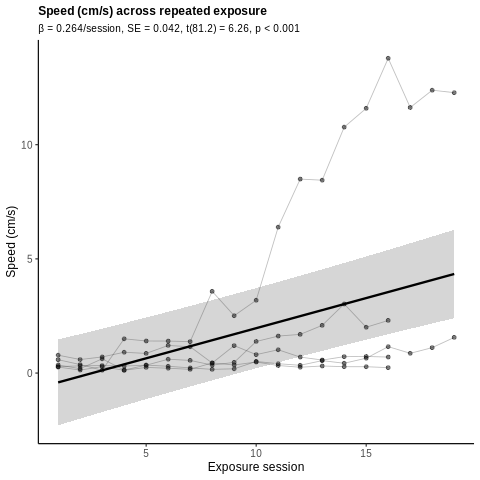

In [16]:
%%R -i hab_session_df -i fig_dir_str

library(lme4)
library(lmerTest)
library(dplyr)
library(ggplot2)

# --------------------------------------------------
# Output folder
# --------------------------------------------------

# out_dir <- "figure_drafts_habituation_whole_session"
# dir.create(out_dir, showWarnings = FALSE)

out_dir <- fig_dir_str

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

hab_session_df$animal <- factor(hab_session_df$animal)

# --------------------------------------------------
# Primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

outcome_labels <- c(
  frac_moving = "Fraction moving",
  frac_forward = "Fraction forward",
  mean_speed_path_cms = "Speed (cm/s)"
)

# --------------------------------------------------
# Helper: p-value formatting
# --------------------------------------------------

format_p <- function(p) {
  if (is.na(p)) {
    return("p = NA")
  } else if (p < 0.001) {
    return("p < 0.001")
  } else {
    return(paste0("p = ", sprintf("%.3f", p)))
  }
}

# --------------------------------------------------
# Helper: fixed-effect prediction with 95% CI
# --------------------------------------------------

predict_fixed_ci <- function(model, newdata) {
  fixed_formula <- formula(model, fixed.only = TRUE)
  X <- model.matrix(delete.response(terms(fixed_formula)), newdata)
  beta <- fixef(model)
  V <- vcov(model)

  fit <- as.numeric(X %*% beta)
  se <- sqrt(diag(X %*% V %*% t(X)))

  newdata$fit <- fit
  newdata$se <- se
  newdata$lower <- fit - 1.96 * se
  newdata$upper <- fit + 1.96 * se

  return(newdata)
}

# --------------------------------------------------
# Theme
# --------------------------------------------------

theme_pub <- function() {
  theme_classic(base_size = 12) +
    theme(
      axis.title = element_text(size = 12),
      axis.text = element_text(size = 10),
      plot.title = element_text(size = 12, face = "bold"),
      plot.subtitle = element_text(size = 10),
      legend.position = "none"
    )
}

# --------------------------------------------------
# Fit models and make plots
# --------------------------------------------------

hab_whole_session_models <- list()
hab_whole_session_plot_data <- list()
hab_whole_session_stats <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Plotting:", outcome, "\n")
  cat("==============================\n")

  # -----------------------------
  # Fit LME
  # -----------------------------

  formula_text <- paste0(
    outcome,
    " ~ exposure_session_c + (1 | animal)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = hab_session_df,
    REML = FALSE
  )

  hab_whole_session_models[[outcome]] <- m

  # -----------------------------
  # Extract slope stats
  # -----------------------------

  sm <- summary(m)
  coef_table <- as.data.frame(sm$coefficients)

  beta <- coef_table["exposure_session_c", "Estimate"]
  se <- coef_table["exposure_session_c", "Std. Error"]
  df <- coef_table["exposure_session_c", "df"]
  tval <- coef_table["exposure_session_c", "t value"]
  pval <- coef_table["exposure_session_c", "Pr(>|t|)"]

  stat_label <- paste0(
    "\u03b2 = ", sprintf("%.3f", beta),
    "/session, SE = ", sprintf("%.3f", se),
    ", t(", sprintf("%.1f", df), ") = ", sprintf("%.2f", tval),
    ", ", format_p(pval)
  )

  hab_whole_session_stats[[outcome]] <- data.frame(
    outcome = outcome,
    beta = beta,
    se = se,
    df = df,
    t = tval,
    p = pval,
    stat_label = stat_label
  )

  # -----------------------------
  # Prediction grid
  # -----------------------------

  exposure_seq <- seq(
    min(hab_session_df$exposure_session, na.rm = TRUE),
    max(hab_session_df$exposure_session, na.rm = TRUE),
    length.out = 100
  )

  exposure_mean <- mean(hab_session_df$exposure_session, na.rm = TRUE)

  pred_df <- data.frame(
    exposure_session = exposure_seq,
    exposure_session_c = exposure_seq - exposure_mean
  )

  pred_df <- predict_fixed_ci(m, pred_df)

  hab_whole_session_plot_data[[outcome]] <- pred_df

  # -----------------------------
  # Plot
  # -----------------------------

  p <- ggplot() +

    # individual animal trajectories
    geom_line(
      data = hab_session_df,
      aes(
        x = exposure_session,
        y = .data[[outcome]],
        group = animal
      ),
      alpha = 0.25,
      linewidth = 0.4
    ) +

    # individual session points
    geom_point(
      data = hab_session_df,
      aes(
        x = exposure_session,
        y = .data[[outcome]]
      ),
      alpha = 0.50,
      size = 1.6
    ) +

    # model CI
    geom_ribbon(
      data = pred_df,
      aes(
        x = exposure_session,
        ymin = lower,
        ymax = upper
      ),
      alpha = 0.20
    ) +

    # model fixed-effect line
    geom_line(
      data = pred_df,
      aes(
        x = exposure_session,
        y = fit
      ),
      linewidth = 1.1
    ) +

    labs(
      title = paste0(outcome_labels[[outcome]], " across repeated exposure"),
      subtitle = stat_label,
      x = "Exposure session",
      y = outcome_labels[[outcome]]
    ) +
    theme_pub()

  print(p)

  # -----------------------------
  # Save vector files
  # -----------------------------

  ggsave(
    filename = file.path(out_dir, paste0("Fig1_whole_session_", outcome, ".pdf")),
    plot = p,
    width = 4.2,
    height = 3.4
  )

  # ggsave(
  #   filename = file.path(out_dir, paste0("Fig1_whole_session_", outcome, ".svg")),
  #   plot = p,
  #   width = 4.2,
  #   height = 3.4
  # )
}

# --------------------------------------------------
# Combine stats table
# --------------------------------------------------

hab_whole_session_stats_df <- bind_rows(hab_whole_session_stats)

print(hab_whole_session_stats_df)

write.csv(
  hab_whole_session_stats_df,
  file.path(out_dir, "habituation_whole_session_LME_stats.csv"),
  row.names = FALSE
)

In [13]:
%%R

# --------------------------------------------------
# Figure 1D-F: within-session dynamics
# --------------------------------------------------

epoch_models <- list()

for (outcome in primary_outcomes) {

  if (!(outcome %in% names(hab_epoch_df))) {
    next
  }

  formula_text <- paste0(
    outcome,
    " ~ exposure_session_c * session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = hab_epoch_df,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  epoch_models[[outcome]] <- m

  # Real session-time axis in minutes
  session_time_seq <- seq(
    min(hab_epoch_df$session_time_min, na.rm = TRUE),
    max(hab_epoch_df$session_time_min, na.rm = TRUE),
    length.out = 100
  )

  session_time_mean <- mean(hab_epoch_df$session_time_min, na.rm = TRUE)

  # Early / mean / late exposure values for visualization
  exposure_min <- min(hab_epoch_df$exposure_session, na.rm = TRUE)
  exposure_mid <- mean(hab_epoch_df$exposure_session, na.rm = TRUE)
  exposure_max <- max(hab_epoch_df$exposure_session, na.rm = TRUE)
  exposure_mean <- mean(hab_epoch_df$exposure_session, na.rm = TRUE)

  exposure_levels <- data.frame(
    exposure_session = c(exposure_min, exposure_mid, exposure_max),
    exposure_label = c("Early exposure", "Mean exposure", "Late exposure")
  )

  pred_df <- expand.grid(
    session_time_min = session_time_seq,
    exposure_session = exposure_levels$exposure_session
  )

  pred_df <- pred_df %>%
    left_join(exposure_levels, by = "exposure_session") %>%
    mutate(
      exposure_session_c = exposure_session - exposure_mean,
      session_time_10m_c = (session_time_min - session_time_mean) / 10
    )

  pred_df <- predict_fixed_ci(m, pred_df)

  # Optional raw binned means for visual reference
  raw_bin_df <- hab_epoch_df %>%
    mutate(
      session_time_bin = floor(session_time_min),
      exposure_group = case_when(
        exposure_session <= quantile(exposure_session, 1/3, na.rm = TRUE) ~ "Early exposure",
        exposure_session >= quantile(exposure_session, 2/3, na.rm = TRUE) ~ "Late exposure",
        TRUE ~ "Mean exposure"
      )
    ) %>%
    group_by(exposure_group, session_time_bin) %>%
    summarise(
      y_mean = mean(.data[[outcome]], na.rm = TRUE),
      .groups = "drop"
    )

  raw_bin_df$exposure_group <- factor(
    raw_bin_df$exposure_group,
    levels = c("Early exposure", "Mean exposure", "Late exposure")
  )

  pred_df$exposure_label <- factor(
    pred_df$exposure_label,
    levels = c("Early exposure", "Mean exposure", "Late exposure")
  )

  p <- ggplot() +
    geom_point(
      data = raw_bin_df,
      aes(
        x = session_time_bin,
        y = y_mean,
        group = exposure_group
      ),
      alpha = 0.35,
      size = 1.3
    ) +
    geom_ribbon(
      data = pred_df,
      aes(
        x = session_time_min,
        ymin = lower,
        ymax = upper,
        group = exposure_label
      ),
      alpha = 0.15
    ) +
    geom_line(
      data = pred_df,
      aes(
        x = session_time_min,
        y = fit,
        group = exposure_label,
        linetype = exposure_label
      ),
      linewidth = 1.0
    ) +
    labs(
      title = paste0(outcome_labels[[outcome]], " across within-session time"),
      x = "Within-session time (min)",
      y = outcome_labels[[outcome]],
      linetype = "Exposure level"
    ) +
    theme_pub()

  print(p)

  ggsave(
    filename = file.path(out_dir, paste0("Fig1_within_session_", outcome, ".pdf")),
    plot = p,
    width = 4.5,
    height = 3.4
  )
}

R[write to console]: Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'hab_epoch_df' not found




Error in (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  : 
  object 'hab_epoch_df' not found


RInterpreterError: Failed to parse and evaluate line '\n# --------------------------------------------------\n# Figure 1D-F: within-session dynamics\n# --------------------------------------------------\n\nepoch_models <- list()\n\nfor (outcome in primary_outcomes) {\n\n  if (!(outcome %in% names(hab_epoch_df))) {\n    next\n  }\n\n  formula_text <- paste0(\n    outcome,\n    " ~ exposure_session_c * session_time_10m_c + ",\n    "(1 | animal) + (1 | animal_day)"\n  )\n\n  m <- lmer(\n    as.formula(formula_text),\n    data = hab_epoch_df,\n    REML = FALSE,\n    control = lmerControl(\n      optimizer = "bobyqa",\n      optCtrl = list(maxfun = 2e5)\n    )\n  )\n\n  epoch_models[[outcome]] <- m\n\n  # Real session-time axis in minutes\n  session_time_seq <- seq(\n    min(hab_epoch_df$session_time_min, na.rm = TRUE),\n    max(hab_epoch_df$session_time_min, na.rm = TRUE),\n    length.out = 100\n  )\n\n  session_time_mean <- mean(hab_epoch_df$session_time_min, na.rm = TRUE)\n\n  # Early / 